# 固定合约对的换月前秒级 spread 研究

本 Notebook 只研究高频盘口问题：由主力切换确定一对固定的展出/展入合约，读取两腿的 `backtest_1s` 最优买卖价，检验换月前这对合约的 spread 是否仍有方向性。数据没有使用 HFQ、连续合约、日线 close 或 Settlement。

## 口径

事件日 `t=0` 由冻结的主力切换表给出。每个事件的 `old_contract`（旧主力、近月）和 `new_contract`（新主力、远月）从事件确定后固定不变；即使主力身份已经切换，也绝不改为当天的主力/次主力组合。

对每个交易日，两腿仅在相同的 UTC 秒 `ts` 同时有有效 BBO 时配对：

- 中间价：`old_mid=(old_bid+old_ask)/2`，`new_mid=(new_bid+new_ask)/2`。
- 中间价差：`mid_spread=old_mid-new_mid`。
- 可执行双腿价差：卖旧买新为 `old_bid-new_ask`；买旧卖新为 `old_ask-new_bid`。
- 为跨品种比较，额外记录 `mid_spread_bps=10000*log(old_mid/new_mid)`；这是相对价差单位，不是年化价差。

每个值只使用当时及过去 59 秒的报价作 60 秒 trailing rolling mean，并在每分钟最后一个可得秒保留一条值。滚动窗口至少有 30 条同秒配对报价才有效，因此不会用未来盘口做平滑。

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display
import pandas as pd

# 从任意 notebook 启动目录定位 mkt_signal 仓库。
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'Cargo.toml').is_file():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('cannot locate the mkt_signal repository root')
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from research.roll_spread.study import StudyParameters, StudyPaths, run_high_frequency_study

PATHS = StudyPaths(
    cn_roll_root=Path('/mnt/nvme-raid0-28t/fanghaizhou/cn_roll_replay/2019_20260826/result_no_rollback'),
    cme_roll_root=Path('/mnt/hdd-raid5-72t/liang_torch/lseg_data/cme_volume_roll_1d'),
    cn_backtest_root=Path('/mnt/hdd-raid5-72t/liang_torch/cn_futures_data/backtest_1s'),
    cme_backtest_root=Path('/mnt/hdd-raid5-72t/liang_torch/lseg_data/backtest_1s'),
)
OUTPUT_DIR = Path('/mnt/nvme-raid0-28t/fanghaizhou/roll_spread_study/20260909_1s_2026_all_events')
PARAMETERS = StudyParameters(
    pre_roll_days=10,
    include_roll_day=False,
    smoothing_seconds=60,
    min_seconds_per_minute=30,
    path_bins=100,
)

# True 会重新读取所有 1s parquet；False 直接复核已落盘的本次结果。
REBUILD = False


In [2]:
if REBUILD:
    results = run_high_frequency_study(
        PATHS,
        OUTPUT_DIR,
        recent_start=pd.Timestamp('2026-01-01'),
        latest_per_product=False,
        parameters=PARAMETERS,
    )
else:
    results = {
        'events': pd.read_csv(OUTPUT_DIR / 'events.csv', parse_dates=['event_date']),
        'jobs': pd.read_csv(OUTPUT_DIR / 'planned_backtest_files.csv', parse_dates=['event_date', 'trading_day']),
        'audit': pd.read_csv(OUTPUT_DIR / 'backtest_file_audit.csv', parse_dates=['event_date', 'trading_day']),
        'trends': pd.read_csv(OUTPUT_DIR / 'event_trends.csv', parse_dates=['event_date']),
        'market_summary': pd.read_csv(OUTPUT_DIR / 'market_trend_summary.csv'),
        'progress': pd.read_csv(OUTPUT_DIR / 'normalized_progress_path.csv'),
    }

results['events'].groupby('market').agg(
    events=('event_id', 'size'),
    products=('product_key', 'nunique'),
    first_roll=('event_date', 'min'),
    last_roll=('event_date', 'max'),
)


,events,products,first_roll,last_roll
market,,,,
CME,12,6,2026-01-15,2026-05-29
CN,316,79,2026-01-07,2026-08-26


## 数据完整性

下表逐一记录计划读取的换月前 10 个交易日文件。`ok` 表示该日旧、新两腿存在有效的同秒 BBO 且产生了至少一条分钟记录；其他状态不能被静默混入样本。

In [3]:
audit_summary = (
    results['audit']
    .groupby(['market', 'status'], as_index=False)
    .agg(files=('status', 'size'), pair_seconds=('pair_seconds', 'sum'), minute_rows=('minute_rows', 'sum'))
)
display(audit_summary)

# 分钟数据很大；按需加载并抽查一个事件，而不是默认塞进 notebook 内存。
sample_event = results['trends'].iloc[0]['event_id']
sample_minutes = pd.read_parquet(
    OUTPUT_DIR / 'minute_spreads.parquet',
    filters=[('event_id', '=', sample_event)],
)
display(sample_minutes.head())


,market,status,files,pair_seconds,minute_rows
0,CME,ok,120,9908880,165150
1,CN,ok,3160,66257585,1104519


,event_id,market,exchange,product,product_key,event_date,old_contract,new_contract,relative_day,trading_day,minute_utc,minute_ts,observed_seconds,mid_spread,mid_spread_bps,sell_old_buy_new_spread,buy_old_sell_new_spread
0,CME:CBOT:YM:20260318:32,CME,CBOT,YM,CME:CBOT:YM,2026-03-18,CBOT:YM:2026-03,CBOT:YM:2026-06,-10,2026-03-04,2026-03-03 23:00:00+00:00,1772578859,59,-310.627119,-63.877173,-327.898305,-293.355932
1,CME:CBOT:YM:20260318:32,CME,CBOT,YM,CME:CBOT:YM,2026-03-18,CBOT:YM:2026-03,CBOT:YM:2026-06,-10,2026-03-04,2026-03-03 23:01:00+00:00,1772578919,60,-310.091667,-63.762777,-326.850000,-293.333333
2,CME:CBOT:YM:20260318:32,CME,CBOT,YM,CME:CBOT:YM,2026-03-18,CBOT:YM:2026-03,CBOT:YM:2026-06,-10,2026-03-04,2026-03-03 23:02:00+00:00,1772578979,60,-309.266667,-63.588721,-326.633333,-291.900000
3,CME:CBOT:YM:20260318:32,CME,CBOT,YM,CME:CBOT:YM,2026-03-18,CBOT:YM:2026-03,CBOT:YM:2026-06,-10,2026-03-04,2026-03-03 23:03:00+00:00,1772579039,60,-309.858333,-63.730866,-322.700000,-297.016667
4,CME:CBOT:YM:20260318:32,CME,CBOT,YM,CME:CBOT:YM,2026-03-18,CBOT:YM:2026-03,CBOT:YM:2026-06,-10,2026-03-04,2026-03-03 23:04:00+00:00,1772579099,60,-309.550000,-63.657862,-320.683333,-298.416667


## 换月前的分钟级路径

每个事件先从自己的第一条分钟 spread 扣除起点，再按它自己的交易分钟进度映射到 100 个等宽格。图中每个事件等权，避免交易时间更长或报价更密的事件主导均值。它是描述性结果：趋势是否能用于交易，还需要预先固定入场时点、方向、双腿成交规则和样本外验证。

,market,progress_bin,mean_delta_mid_spread_bps,events
0,CME,0,0.000000,12
50,CME,50,-24.135042,12
100,CME,100,-57.421891,12
101,CN,0,0.000000,316
151,CN,50,-2.711485,316
201,CN,100,-14.508954,316


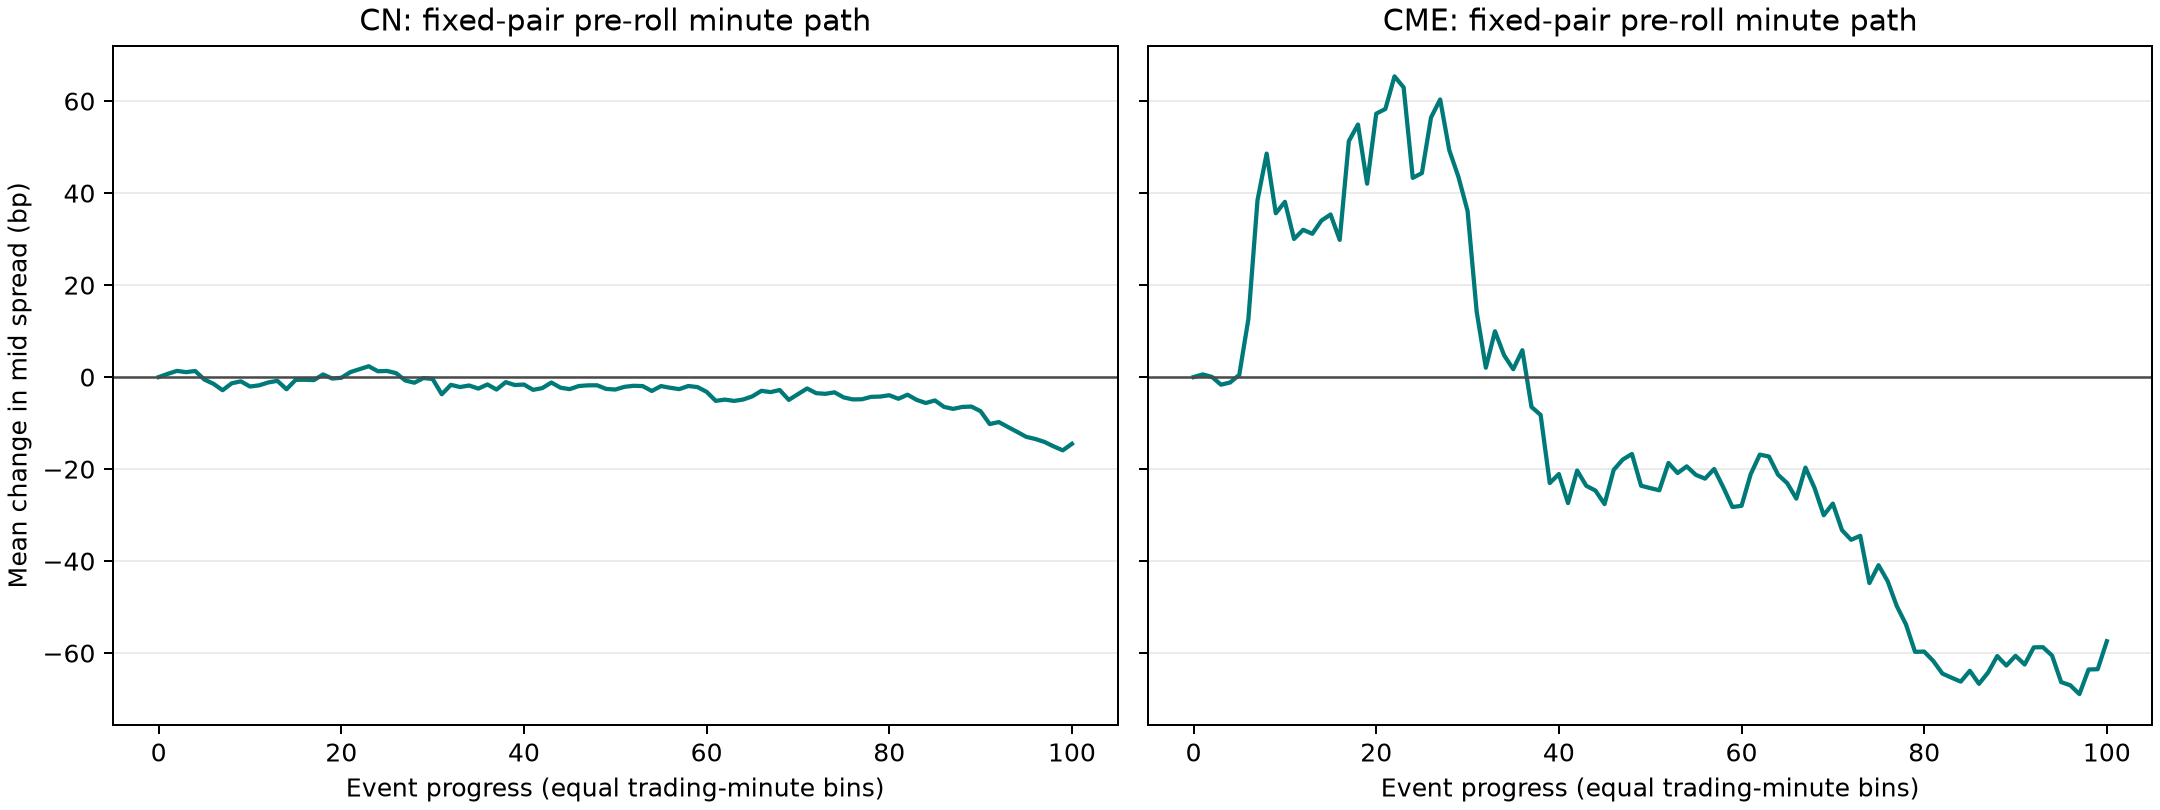

In [4]:
display(results['progress'].query('progress_bin in [0, 50, 100]').sort_values(['market', 'progress_bin']))
Image(filename=str(OUTPUT_DIR / 'minute_spread_path.png'))


## 单事件趋势分布

这里对每个事件的分钟级 `mid_spread_bps` 按交易分钟序号拟合一条直线，斜率单位为每 1,000 个交易分钟的 bp。正斜率表示旧合约相对新合约走强，负斜率表示旧合约相对新合约走弱。它不等于可交易收益，真实交易需要用上面的两种可执行 BBO spread 加入手续费、同步成交和持有/平仓规则。

,market,events,mean_raw_slope_bps_per_1000_trading_minutes,median_raw_slope_bps_per_1000_trading_minutes,positive_raw_slope_share,state_events,mean_state_continuation_change_bps,median_state_continuation_change_bps,positive_state_continuation_share,momentum_events,mean_momentum_continuation_change_bps,median_momentum_continuation_change_bps,positive_momentum_continuation_share
0,CME,12,-8.620833,0.019593,0.500000,12,-57.572217,-0.633713,0.416667,12,33.864863,0.797036,0.500000
1,CN,316,-3.787915,-0.651629,0.462025,316,4.640712,-0.663444,0.493671,316,-4.942453,-1.125557,0.481013


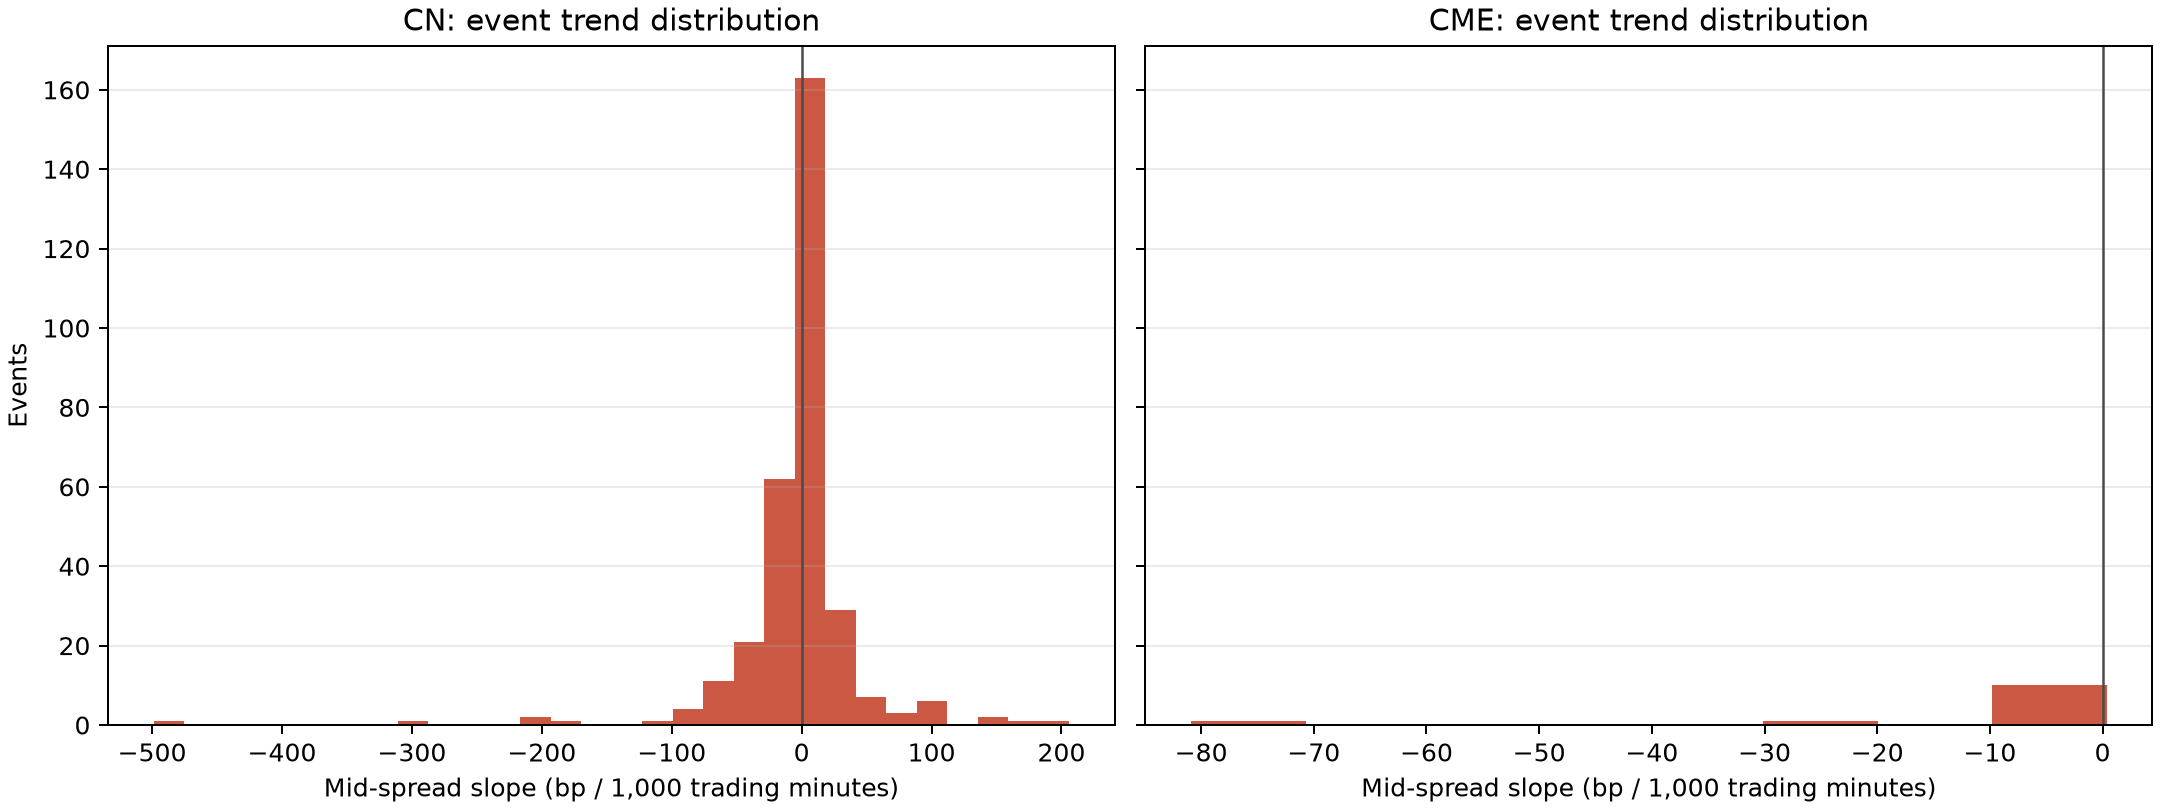

In [5]:
# state_continuation: 首分钟已知的结构是否在窗口内加深。
# momentum_continuation: 前 50% 交易分钟的变动是否在后 50% 延续。
display(results['market_summary'])
Image(filename=str(OUTPUT_DIR / 'event_trend_distribution.png'))


## 可复现与下一步

当前默认范围是 2026-01-01 以后至数据终点的全部换月事件。state_continuation 在窗口首分钟确定 Backwardation 或 Contango 后，衡量结构是否加深；momentum_continuation 在前 50% 交易分钟确定方向后，衡量后 50% 是否同向。它们仍是描述性检验，完整交易研究还应在更长历史上划分训练/验证/样本外区间，预先固定持仓方向、费用、双腿同步成交和流动性门槛。输出目录保留事件、逐文件审计、完整分钟数据、事件统计、市场汇总和图表。